<div style="font-family: 'Times New Roman'; color:darkblue; font-size:20px;">

<h1 style="color:red; font-size:25px;"> Transit Demand Prediction</h1>

<h2 style="color:red; font-size:22px;"> Context</h2>

This dataset is designed to model and predict <b>public transit demand</b> (bus, metro, or shared mobility usage) based on various influencing factors such as <b>population density, weather conditions, day type, distance to nearest stops, and socioeconomic data</b>.

The objective is to build a <b>machine learning model</b> that predicts the expected number of commuters (or trip count) for a given region or time period. Such predictions can help in:
<ul>
<li>Optimizing <b>transit scheduling</b>,</li>
<li>Improving <b>fleet allocation</b>, and</li>
<li>Enhancing <b>sustainability and passenger convenience</b>.</li>
</ul>

Several constraints are considered, such as:
<ul>
<li>Data variability across <b>time of day</b> and <b>day of week</b>,</li>
<li>External factors like <b>weather and events</b>, and</li>
<li><b>Geospatial factors</b> like proximity to major roads or city centers.</li>
</ul>

<hr>

<h2 style="color:red; font-size:22px;"> Objective</h2>

To predict <b>daily or hourly transit demand</b> using machine learning, and evaluate multiple algorithms to find the best performing one.

<hr>

<h2 style="color:red; font-size:22px;"> Importing Required Libraries</h2>

</div>


<div style="font-family: 'Times New Roman';">

<h2 style="color:red; font-size:22px;"> Step 1 — Importing Required Libraries</h2>

<p style="color:darkblue; font-size:20px;">
In this section, we import the essential Python libraries used for <b>data handling, visualization, and machine learning.</b>  
Each library serves a specific purpose:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>Pandas & NumPy</b> — For data manipulation, numerical operations, and dataset preparation.</li>
<li><b>Matplotlib & Seaborn</b> — For data visualization and exploratory data analysis (EDA).</li>
<li><b>Scikit-learn</b> — For data preprocessing, model building, and performance evaluation.</li>
<li><b>XGBoost</b> — For efficient gradient boosting regression with high predictive power.</li>
<li><b>Joblib</b> — To save and load trained machine learning models.</li>
<li><b>Warnings</b> — To suppress unnecessary system warnings during execution.</li>
</ul>

</div>


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')
print(" Libraries Imported")


 Libraries Imported


<div style="font-family: 'Times New Roman';">

<h2 style="color:red; font-size:22px;"> Step 2 — Load or Create Dataset</h2>

<p style="color:darkblue; font-size:20px;">
In this step, we either <b>load an existing dataset</b> or <b>generate a synthetic dataset</b> for modeling transit demand.  
If a real dataset (CSV file) is available, we can use:
</p>

<p style="color:darkblue; font-size:20px;"><code>pd.read_csv("your_dataset.csv")</code></p>

<p style="color:darkblue; font-size:20px;">
However, to demonstrate the workflow, a <b>synthetic dataset</b> is created with the following features:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>zone</b> — Transit zone or region label (Z1–Z4).</li>
<li><b>hour</b> — Hour of the day (0–23).</li>
<li><b>day</b> — Day of the week (Mon–Sun).</li>
<li><b>weather</b> — Weather condition (Clear, Cloudy, Rainy).</li>
<li><b>event</b> — Indicates if a special event is happening (0 = No, 1 = Yes).</li>
</ul>

<p style="color:darkblue; font-size:20px;">
These features are combined with certain factors (<b>base demand, time of day, day type, weather, events, and random noise</b>)  
to simulate realistic passenger demand values.
</p>

</div>


In [3]:
np.random.seed(42)
n = 2000

data = pd.DataFrame({
    'zone': np.random.choice(['Z1','Z2','Z3','Z4'], n),
    'hour': np.random.randint(0,24,n),
    'day': np.random.choice(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], n),
    'weather': np.random.choice(['Clear','Cloudy','Rainy'], n),
    'event': np.random.choice([0,1], n, p=[0.9,0.1])
})

# Simulate demand pattern
zone_base = {'Z1':60, 'Z2':90, 'Z3':120, 'Z4':70}
data['base'] = data['zone'].map(zone_base)
data['hour_factor'] = data['hour'].apply(lambda h: 40 if 7<=h<=9 or 17<=h<=19 else 0)
data['day_factor'] = data['day'].apply(lambda d: 25 if d in ['Sat','Sun'] else 0)
data['weather_factor'] = data['weather'].apply(lambda w: -10 if w=='Clear' else (0 if w=='Cloudy' else 15))
data['event_factor'] = data['event']*80
data['noise'] = np.random.normal(0,10,n)

# Calculate final passenger demand
data['demand'] = (data['base'] + data['hour_factor'] + data['day_factor'] +
                  data['weather_factor'] + data['event_factor'] + data['noise']).astype(int)

# Drop helper columns
data.drop(columns=['base','hour_factor','day_factor','weather_factor','event_factor','noise'], inplace=True)

print("Data Created. Shape:", data.shape)
data.head()


Data Created. Shape: (2000, 6)


,zone,hour,day,weather,event,demand
0,Z3,14,Sat,Cloudy,0,159
1,Z4,11,Fri,Cloudy,0,71
2,Z1,15,Sun,Rainy,0,102
3,Z3,23,Sun,Clear,0,147
4,Z3,18,Mon,Clear,0,151


<div style="font-family: 'Times New Roman';">

<h2 style="color:red; font-size:22px;"> Step 3 — Data Check and Summary</h2>

<p style="color:darkblue; font-size:20px;">
Before proceeding with analysis, we perform a basic <b>data quality check</b> to ensure that the dataset is clean and ready for modeling.  
This step includes:
</p>

<ul style="color:darkblue; font-size:20px;">
<li>Displaying dataset information — to view column names, data types, and memory usage.</li>
<li>Checking for <b>missing values</b> in each column.</li>
<li>Generating a <b>summary of the “demand”</b> variable to understand its distribution and range.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
These checks help confirm that the dataset has the expected structure and no missing or corrupted entries.
</p>

</div>


In [4]:
# STEP 3 — DATA CHECK
# --------------------------------------------
print(data.info())
print("\nMissing values:\n", data.isnull().sum())
print("\nDemand summary:\n", data['demand'].describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   zone     2000 non-null   object
 1   hour     2000 non-null   int32 
 2   day      2000 non-null   object
 3   weather  2000 non-null   object
 4   event    2000 non-null   int32 
 5   demand   2000 non-null   int32 
dtypes: int32(3), object(3)
memory usage: 70.4+ KB
None

Missing values:
 zone       0
hour       0
day        0
weather    0
event      0
demand     0
dtype: int64

Demand summary:
 count    2000.000000
mean      110.161000
std        41.009718
min        21.000000
25%        80.000000
50%       104.000000
75%       134.000000
max       285.000000
Name: demand, dtype: float64


<div style="font-family: 'Times New Roman';">

<h2 style="color:red; font-size:22px;">Step: 4  Exploratory Data Analysis (EDA)</h2>

<p style="color:darkblue; font-size:20px;">
In this step, we explore and visualize the dataset to understand key <b>patterns, trends, and relationships</b> in transit demand.  
EDA helps us gain insights that will later guide feature selection and model building.
</p>

<p style="color:darkblue; font-size:20px;">
The following visualizations are included:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>Demand Distribution:</b> A histogram with KDE curve showing how passenger demand is distributed across all samples.</li>
<li><b>Average Demand by Hour:</b> A point plot displaying how average demand varies throughout the day — identifying peak hours.</li>
<li><b>Demand vs Weather:</b> A boxplot comparing demand under different weather conditions.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
These plots help in recognizing the impact of <b>time, weather, and other contextual factors</b> on passenger demand.
</p>

</div>


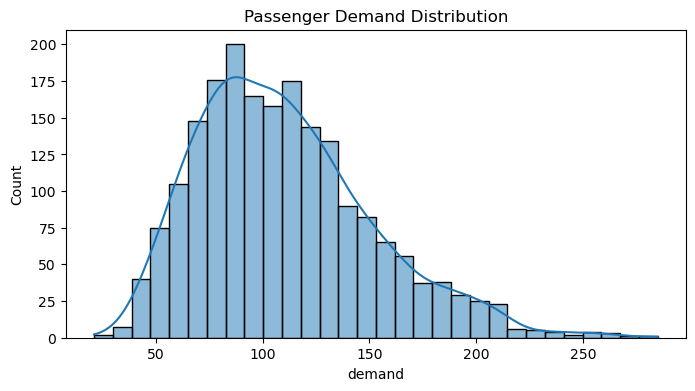

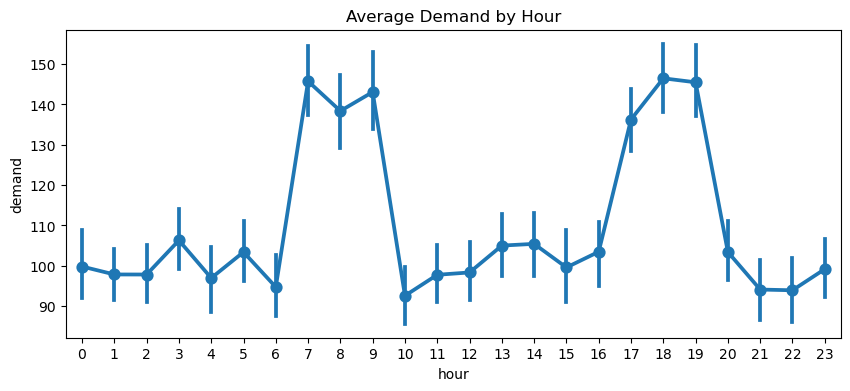

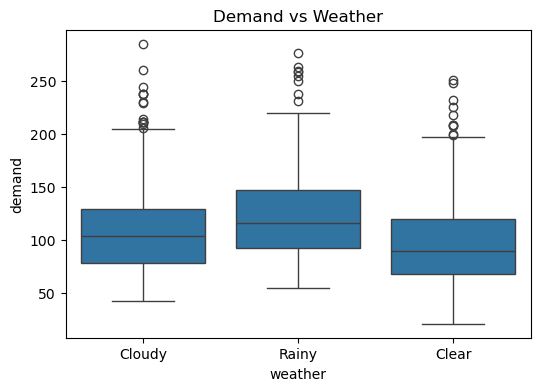

In [8]:

plt.figure(figsize=(8,4))
sns.histplot(data['demand'], bins=30, kde=True)
plt.title("Passenger Demand Distribution")
plt.show()

plt.figure(figsize=(10,4))
sns.pointplot(x='hour', y='demand', data=data, estimator=np.mean)
plt.title("Average Demand by Hour")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='weather', y='demand', data=data)
plt.title("Demand vs Weather")
plt.show()


<div style="font-family: 'Times New Roman';">

<h2 style="color:red; font-size:22px;">Step 4 — Interpretation of EDA Visualizations</h2>

<p style="color:darkblue; font-size:20px;">
After generating the exploratory visualizations, we can interpret each graph to understand important patterns in transit demand data.  
These insights help in identifying which features have the greatest influence on passenger flow.
</p>

<h3 style="color:red; font-size:22px;">1️ Passenger Demand Distribution (Histogram + KDE)</h3>

<p style="color:darkblue; font-size:20px;">
This plot shows the <b>overall distribution of passenger demand</b> across all samples.  
The x-axis represents demand (number of passengers), and the y-axis represents its frequency.
</p>

<ul style="color:darkblue; font-size:20px;">
<li>If the curve appears bell-shaped, it suggests that demand is approximately normally distributed.</li>
<li>A right-skewed curve indicates that high-demand cases (e.g., events or peak hours) occur occasionally.</li>
<li>A left-skewed curve would mean that low-demand situations are more frequent.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
Understanding this shape helps decide if data scaling or transformation is needed before modeling.
</p>

<h3 style="color:red; font-size:22px;">2️ Average Demand by Hour (Point Plot)</h3>

<p style="color:darkblue; font-size:20px;">
This visualization shows how <b>average passenger demand changes throughout the day</b>.  
Typically, the plot displays clear peaks around <b>7–9 AM</b> and <b>5–7 PM</b>, indicating morning and evening rush hours.
</p>

<ul style="color:darkblue; font-size:20px;">
<li>Demand increases sharply during commuting hours when people travel to and from work or school.</li>
<li>It drops during midday and late-night hours.</li>
<li>This trend confirms that <b>hour of the day</b> is a highly influential feature.</li>
</ul>

<h3 style="color:red; font-size:22px;">3️ Demand vs Weather (Box Plot)</h3>

<p style="color:darkblue; font-size:20px;">
This boxplot compares <b>passenger demand under different weather conditions</b>.  
Each box shows the median, interquartile range (IQR), and outliers for each weather type.
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>Rainy days</b> generally have higher median demand — passengers prefer public transport over walking or cycling.</li>
<li><b>Clear weather</b> shows relatively lower demand, as more people might choose alternative modes of transport.</li>
<li><b>Cloudy weather</b> usually lies between the two extremes.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
This visualization reveals that <b>weather significantly influences travel behavior</b> and should be included in demand prediction models.
</p>

<h3 style="color:red; font-size:22px;">🧠 Overall Summary</h3>

<ul style="color:darkblue; font-size:20px;">
<li>Passenger demand patterns strongly depend on <b>time of day</b> and <b>weather conditions</b>.</li>
<li>The dataset reflects realistic commuter trends with visible morning and evening peaks.</li>
<li>Such insights validate that the simulated dataset behaves like a real-world transit system, making it ideal for predictive modeling.</li>
</ul>

</div>


<div style="font-family: 'Times New Roman';">

<h2 style="color:red; font-size:22px;"> Step 5 — Feature Engineering</h2>

<p style="color:darkblue; font-size:20px;">
Feature Engineering is the process of transforming raw data into meaningful input features that improve the performance and accuracy of machine learning models.  
In this step, we create new derived variables and prepare the dataset for training by encoding categorical data into numeric form.
</p>

<h3 style="color:red; font-size:22px;"> Creating New Meaningful Features</h3>

<p style="color:darkblue; font-size:20px;">
Three new features are added based on logical conditions that capture important behavioral patterns:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>is_peak:</b> A binary feature (1 or 0) that identifies peak hours (7–9 AM and 5–7 PM).  
These are the times when transit demand is typically highest.</li>

<li><b>is_weekend:</b> A binary feature marking weekends (<b>Saturday and Sunday</b>) as 1, and weekdays as 0.  
This helps the model capture reduced or changed travel patterns during weekends.</li>

<li><b>rain_event:</b> A combined feature that is set to 1 when both <b>rainy weather</b> and a <b>special event</b> occur on the same day.  
Such combinations often lead to a significant spike in passenger demand.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
These engineered features provide the model with additional context, allowing it to better recognize patterns that directly influence transit demand.
</p>

<h3 style="color:red; font-size:22px;">Converting Categorical Features using One-Hot Encoding</h3>

<p style="color:darkblue; font-size:20px;">
Categorical variables such as <b>zone</b>, <b>day</b>, and <b>weather</b> cannot be directly interpreted by machine learning algorithms.  
To handle this, we use <b>one-hot encoding</b>, which converts each category into binary indicator columns (0 or 1).  
The parameter <b>drop_first=True</b> avoids dummy variable traps by dropping one reference column per category.
</p>

<p style="color:darkblue; font-size:20px;">
After encoding, the dataset becomes fully numeric and ready for the next stages — data splitting, model training, and evaluation.
</p>

<h3 style="color:red; font-size:22px;"> Summary</h3>

<ul style="color:darkblue; font-size:20px;">
<li>Added new derived features: <b>is_peak</b>, <b>is_weekend</b>, and <b>rain_event</b>.</li>
<li>Applied <b>One-Hot Encoding</b> to categorical columns for model compatibility.</li>
<li>The final output is a clean, structured, and model-ready dataset with an increased number of informative features.</li>
</ul>

</div>


In [10]:

# Create new meaningful features
data['is_peak'] = data['hour'].apply(lambda h: 1 if (7<=h<=9) or (17<=h<=19) else 0)
data['is_weekend'] = data['day'].apply(lambda d: 1 if d in ['Sat','Sun'] else 0)
data['rain_event'] = data.apply(lambda x: 1 if x['weather']=='Rainy' and x['event']==1 else 0, axis=1)



In [11]:
data_encoded = pd.get_dummies(data, columns=['zone','day','weather'], drop_first=True)

In [13]:
print(" Feature Engineering Done. Shape:", data_encoded.shape)
data_encoded.head()

 Feature Engineering Done. Shape: (2000, 17)


,hour,event,demand,is_peak,is_weekend,rain_event,zone_Z2,zone_Z3,zone_Z4,day_Mon,day_Sat,day_Sun,day_Thu,day_Tue,day_Wed,weather_Cloudy,weather_Rainy
0,14,0,159,0,1,0,False,True,False,False,True,False,False,False,False,True,False
1,11,0,71,0,0,0,False,False,True,False,False,False,False,False,False,True,False
2,15,0,102,0,1,0,False,False,False,False,False,True,False,False,False,False,True
3,23,0,147,0,1,0,False,True,False,False,False,True,False,False,False,False,False
4,18,0,151,1,0,0,False,True,False,True,False,False,False,False,False,False,False


<div style="font-family: 'Times New Roman';">

<h2 style="color:red; font-size:22px;"> Step 5 — Feature Engineering: Output Explanation</h2>

<p style="color:darkblue; font-size:20px;">
After performing feature engineering, the output displays two key pieces of information:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>Message:</b> “ Feature Engineering Done. Shape: (2000, N)” —  
This confirms that all the new features have been successfully created and added to the dataset.  
The number <b>2000</b> indicates the total rows (records), while <b>N</b> represents the updated number of columns after encoding.</li>

<li><b>Head of the Dataset:</b> The output table shows the first few rows (usually 5) of the transformed dataset <code>data_encoded</code>.</li>
</ul>

<h3 style="color:red; font-size:22px;"> What You’ll Observe in the Output Table</h3>

<ul style="color:darkblue; font-size:20px;">
<li>Each row represents one travel record with its corresponding features.</li>
<li>New columns such as <b>is_peak</b>, <b>is_weekend</b>, and <b>rain_event</b> appear at the end of the dataset.</li>
<li>Categorical features like <b>zone</b>, <b>day</b>, and <b>weather</b> are replaced by multiple binary columns (for example, <b>zone_Z2</b>, <b>zone_Z3</b>, <b>day_Tue</b>, <b>weather_Rainy</b> etc.). Each takes the value <b>0</b> or <b>1</b>.</li>
<li>The <b>demand</b> column remains the target variable, showing integer passenger counts.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
The output confirms that the dataset is now fully numeric, organized, and enriched with additional context features.  
This cleaned dataset (<code>data_encoded</code>) will be used for model training and testing in the next step.
</p>

</div>


<div style="font-family: 'Times New Roman';">

<h2 style="color:red; font-size:22px;"> Step 6 — Split and Scale Data</h2>

<p style="color:darkblue; font-size:20px;">
In this step, the dataset is prepared for model training by splitting it into training and testing parts, followed by scaling the features.  
This ensures that the model can learn patterns efficiently and generalize well to unseen data.
</p>

<h3 style="color:red; font-size:22px;"> Process Explanation</h3>

<ul style="color:darkblue; font-size:20px;">
<li><b>Feature-Target Separation:</b>  
The dataset is divided into two parts — <code>X</code> (features) and <code>y</code> (target).  
Here, <code>demand</code> is the target variable we aim to predict, while all other columns form the feature set.</li>

<li><b>Train-Test Split:</b>  
The dataset is split into two subsets using an 80–20 ratio:  
<ul>
<li><code>X_train</code> and <code>y_train</code> — used for training the model.</li>
<li><code>X_test</code> and <code>y_test</code> — used to evaluate the model’s performance on unseen data.</li>
</ul>
A fixed random state (<code>42</code>) ensures reproducibility of results.</li>

<li><b>Feature Scaling:</b>  
Since the features have different units and magnitudes, a <b>StandardScaler</b> is used to normalize them.  
It transforms each feature so that it has a <b>mean of 0</b> and a <b>standard deviation of 1</b>.  
This prevents large-valued features from dominating the model learning process.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
After scaling, both training and test feature sets (<code>X_train_scaled</code> and <code>X_test_scaled</code>) are ready for use in the modeling phase.  
Scaling ensures that all features contribute equally to the prediction process.
</p>

</div>


In [15]:
X = data_encoded.drop('demand', axis=1)
y = data_encoded['demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Split and Scaled")


Data Split and Scaled


<div style="font-family: 'Times New Roman';">

<h2 style="color:red; font-size:22px;"> Step 6 — Output Explanation: Split and Scale Data</h2>

<p style="color:darkblue; font-size:20px;">
Once the code is executed, you will see the message:
</p>

<p style="color:darkblue; font-size:20px; margin-left: 30px;">
<b>Data Split and Scaled</b>
</p>

<p style="color:darkblue; font-size:20px;">
This message confirms that the data preprocessing process has been successfully completed.  
Let’s understand what this implies:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>Data Split:</b>  
The dataset has been divided into two separate parts:
<ul>
<li><b>Training Data (80%)</b> — Used to train and fit the machine learning models.</li>
<li><b>Testing Data (20%)</b> — Used later to evaluate the performance of those models on unseen data.</li>
</ul>
</li>

<li><b>Scaling Completed:</b>  
All numeric features in the training and testing sets are now standardized using the <b>StandardScaler</b>.  
This transformation ensures that each feature has a mean of <b>0</b> and a standard deviation of <b>1</b>.</li>

<li><b>Resulting Data:</b>  
The new scaled datasets — <code>X_train_scaled</code> and <code>X_test_scaled</code> — are now in numerical format and normalized.  
They are stored as NumPy arrays and will be used for model training in the next step.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
In summary, this output indicates that the dataset has been correctly partitioned and standardized,  
making it ready for building and comparing multiple prediction models in the upcoming steps.
</p>

</div>


<div style="font-family: 'Times New Roman';">

<h2 style="color:red; font-size:22px;"> Step 7 — Train Base Models</h2>

<p style="color:darkblue; font-size:20px;">
In this step, we build and evaluate multiple base machine learning models to identify which one performs best in predicting transit demand.  
The models are trained using the preprocessed (scaled) data, and their performance is measured using standard regression metrics.
</p>

<h3 style="color:red; font-size:22px;"> Process Explanation</h3>

<ul style="color:darkblue; font-size:20px;">
<li><b>Model Selection:</b>  
Four popular regression models are used to start the comparison:
    <ul>
        <li><b>Linear Regression</b> — A simple model assuming a linear relationship between features and target.</li>
        <li><b>Random Forest Regressor</b> — An ensemble model that combines multiple decision trees for higher accuracy.</li>
        <li><b>Gradient Boosting Regressor</b> — A boosting technique that sequentially improves model performance by minimizing errors.</li>
        <li><b>XGBoost Regressor</b> — A powerful, optimized boosting algorithm known for high speed and accuracy.</li>
    </ul>
</li>

<li><b>Training and Evaluation:</b>  
Each model is trained on the training set (<code>X_train_scaled</code>, <code>y_train</code>) and then tested on the unseen data (<code>X_test_scaled</code>, <code>y_test</code>).  
The performance of each model is evaluated using the following metrics:
    <ul>
        <li><b>MAE (Mean Absolute Error):</b> Measures average absolute difference between predicted and actual demand values.</li>
        <li><b>RMSE (Root Mean Squared Error):</b> Penalizes larger errors more strongly than MAE.</li>
        <li><b>R² Score:</b> Indicates how well the model explains variance in the target variable (closer to 1 = better fit).</li>
    </ul>
</li>

<li><b>Result Compilation:</b>  
The results for all models are stored in a table (<code>results_df</code>) and sorted by the highest <b>R² score</b> to easily identify the best-performing model.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
By the end of this step, we can visually compare each model’s accuracy and determine which one will be fine-tuned further for optimal performance.
</p>

</div>


<div style="font-family: 'Times New Roman';">

<h2 style="color:red; font-size:22px;"> Step 7 — Training Individual Models</h2>

<p style="color:darkblue; font-size:20px;">
In this step, multiple machine learning regression models are trained individually on the preprocessed dataset.  
Each trained model is then saved as a <code>.pkl</code> file using the <b>Joblib</b> library for future reuse.  
This allows you to load and evaluate models later without retraining.
</p>

<h3 style="color:red; font-size:22px;"> Process Explanation</h3>

<ul style="color:darkblue; font-size:20px;">
<li><b>Linear Regression:</b>  
A basic statistical model that fits a straight-line relationship between input features and the target variable (passenger demand).</li>

<li><b>Random Forest Regressor:</b>  
An ensemble model made up of many decision trees.  
It reduces overfitting and improves prediction accuracy by averaging results from multiple trees.</li>

<li><b>Gradient Boosting Regressor:</b>  
A sequential model that builds trees one after another, correcting errors made by previous trees to achieve higher precision.</li>

<li><b>XGBoost Regressor:</b>  
An optimized version of gradient boosting known for its efficiency and accuracy.  
It is widely used in real-world machine learning competitions for structured data.</li>
</ul>

<h3 style="color:red; font-size:22px;"> Model Saving</h3>

<p style="color:darkblue; font-size:20px;">
Each trained model is saved using the <code>joblib.dump()</code> function.  
This step ensures that the trained models (<b>Linear Regression</b>, <b>Random Forest</b>, <b>Gradient Boosting</b>, and <b>XGBoost</b>)  
can be reloaded later for testing, comparison, or deployment without repeating the training process.
</p>

<p style="color:darkblue; font-size:20px;">
After successful training, confirmation messages  appear, indicating that the model has been trained and saved properly.
</p>

</div>


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import joblib

<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:22px;"> Step 7.1 — Training Linear Regression Model</h2>

<p style="color:darkblue; font-size:20px;">
This section focuses on building the <b>Linear Regression</b> model — the simplest and most interpretable regression algorithm.  
It assumes a <b>linear relationship</b> between the independent features (such as hour, weather, zone, etc.) and the target variable (<b>passenger demand</b>).
</p>

<h3 style="color:red; font-size:22px;">Process Explanation</h3>

<ul style="color:darkblue; font-size:20px;">
<li><b>Model Initialization:</b>  
The <code>LinearRegression()</code> object is created to represent a straight-line model that fits the best linear combination of input features.</li>

<li><b>Training the Model:</b>  
The <code>fit()</code> function is applied on the scaled training data (<code>X_train_scaled</code>, <code>y_train</code>).  
This step estimates the best-fit coefficients (weights) for each feature that minimize prediction error.</li>

<li><b>Model Saving:</b>  
After training, the model is stored as <code>linear_regression_model.pkl</code> using the <b>Joblib</b> library.  
Saving the model ensures that it can be re-used later for prediction or evaluation without retraining.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
When you run this cell, messages appear such as:
</p>

<p style="color:darkblue; font-size:20px; margin-left:30px;">
 Training Linear Regression...  
 Linear Regression model saved.
</p>

<p style="color:darkblue; font-size:20px;">
These confirmations indicate that the model has been successfully trained on the dataset and saved locally for future use.
</p>

</div>


In [17]:
print("Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
joblib.dump(lr, "linear_regression_model.pkl")
print(" Linear Regression model saved.\n")


Training Linear Regression...
 Linear Regression model saved.



<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:22px;"> Step 7.2 — Training Random Forest Model</h2>

<p style="color:darkblue; font-size:20px;">
In this step, the <b>Random Forest Regressor</b> model is trained to predict passenger demand.  
Random Forest is an <b>ensemble learning technique</b> that combines predictions from multiple decision trees to produce more accurate and stable results.
</p>

<h3 style="color:red; font-size:22px;"> Process Explanation</h3>

<ul style="color:darkblue; font-size:20px;">
<li><b>Model Initialization:</b>  
A <code>RandomForestRegressor()</code> is created with a fixed <code>random_state</code> for reproducibility.  
The model constructs multiple decision trees during training and merges their predictions for higher accuracy.</li>

<li><b>Training the Model:</b>  
The <code>fit()</code> method is applied on <code>X_train_scaled</code> and <code>y_train</code>.  
Each tree in the forest learns patterns from random subsets of data and features, reducing overfitting and improving generalization.</li>

<li><b>Model Saving:</b>  
After training, the model is saved as <code>random_forest_model.pkl</code> using the <b>Joblib</b> library.  
Saving ensures you can reuse the model later for predictions or deployment without retraining it.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
When this cell is executed, you will see confirmation messages:
</p>

<p style="color:darkblue; font-size:20px; margin-left:30px;">
 Training Random Forest...  
 Random Forest model saved.
</p>

<p style="color:darkblue; font-size:20px;">
These outputs confirm that the Random Forest model has been successfully trained and saved for future evaluation or comparison with other models.
</p>

</div>


In [18]:
print(" Training Random Forest...")
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)
joblib.dump(rf, "random_forest_model.pkl")
print(" Random Forest model saved.\n")


 Training Random Forest...
 Random Forest model saved.



<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:22px;"> Step 7.3 — Training Gradient Boosting Model</h2>

<p style="color:darkblue; font-size:20px;">
In this step, the <b>Gradient Boosting Regressor</b> is trained to improve prediction accuracy using a boosting approach.  
Unlike Random Forest, which trains trees independently, Gradient Boosting builds trees <b>sequentially</b>, where each new tree corrects the errors made by the previous ones.
</p>

<h3 style="color:red; font-size:22px;"> Process Explanation</h3>

<ul style="color:darkblue; font-size:20px;">
<li><b>Model Initialization:</b>  
A <code>GradientBoostingRegressor()</code> is created with a fixed <code>random_state</code> for reproducibility.  
The model applies gradient descent to minimize prediction errors over iterations.</li>

<li><b>Training the Model:</b>  
The <code>fit()</code> method is used on <code>X_train_scaled</code> and <code>y_train</code>.  
Each iteration adds a new tree that focuses on reducing residual errors from the previous stage, allowing the model to learn complex nonlinear relationships effectively.</li>

<li><b>Model Saving:</b>  
After training, the model is saved as <code>gradient_boosting_model.pkl</code> using the <b>Joblib</b> library.  
This ensures the trained model can be reused later without retraining.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
When this cell runs, you will see:
</p>

<p style="color:darkblue; font-size:20px; margin-left:30px;">
 Training Gradient Boosting...  
 Gradient Boosting model saved.
</p>

<p style="color:darkblue; font-size:20px;">
This confirms that the Gradient Boosting model has been successfully trained and stored for comparison with other algorithms.
</p>

</div>


In [19]:
print(" Training Gradient Boosting...")
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train_scaled, y_train)
joblib.dump(gb, "gradient_boosting_model.pkl")
print(" Gradient Boosting model saved.\n")


 Training Gradient Boosting...
 Gradient Boosting model saved.



<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> Step 7.4 — Training the XGBoost Model</h2>

<p style="color:darkblue; font-size:20px;">
In this step, we use the <b>XGBoost (Extreme Gradient Boosting)</b> algorithm, one of the most powerful and efficient ensemble techniques for regression and classification tasks.  
It builds upon Gradient Boosting by optimizing both performance and speed through parallel computation and advanced regularization methods.  
XGBoost is known for its high accuracy and efficiency in handling large datasets with complex relationships.
</p>

<h3 style="color:red; font-size:25px;">Explanation</h3>

<ul style="color:darkblue; font-size:20px;">
<li><b>Model Initialization:</b>  
We initialize the model using <code>XGBRegressor(objective='reg:squarederror', random_state=42)</code>.  
The <code>objective='reg:squarederror'</code> specifies that the task is a regression problem, and <code>random_state</code> ensures reproducibility.</li>

<li><b>Training the Model:</b>  
The <code>fit()</code> method trains the model on <code>X_train_scaled</code> and <code>y_train</code>.  
XGBoost builds multiple weak learners (decision trees) sequentially, where each new tree tries to minimize the previous model’s prediction error by adjusting residuals efficiently.</li>

<li><b>Regularization:</b>  
XGBoost includes both L1 (Lasso) and L2 (Ridge) regularization to prevent overfitting and improve model generalization — making it more robust than standard Gradient Boosting.</li>

<li><b>Model Saving:</b>  
Once training is complete, the model is saved as <code>xgboost_model.pkl</code> using <b>Joblib</b>.  
This allows you to reuse or deploy the trained model later without retraining.</li>
</ul>

<h3 style="color:red; font-size:25px;"> Output Message</h3>
<p style="color:darkblue; font-size:20px;">
When you execute this cell, you will see the following messages:<br>
 Training XGBoost...<br>
 XGBoost model saved.<br><br>
These messages confirm that the XGBoost model has been successfully trained and stored for later use.
</p>

</div>


In [23]:
 #Train XGBoost
print(" Training XGBoost...")
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb.fit(X_train_scaled, y_train)
joblib.dump(xgb, "xgboost_model.pkl")
print(" XGBoost model saved.\n")

 Training XGBoost...
 XGBoost model saved.



<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> Step 8 — Evaluating Trained Models</h2>

<p style="color:darkblue; font-size:20px;">
After training multiple models, the next crucial step is to <b>evaluate their performance</b> on the unseen test data.  
This helps us determine which model best predicts passenger demand by comparing key error metrics.  
The evaluation is performed using standard regression performance indicators such as <b>MAE</b>, <b>RMSE</b>, and <b>R²</b>.
</p>

<h3 style="color:red; font-size:25px;"> Explanation</h3>

<ul style="color:darkblue; font-size:20px;">
<li><b>Function Definition:</b>  
A reusable function <code>evaluate_model()</code> is defined to compute and print the evaluation metrics for each trained model.</li>

<li><b>Evaluation Metrics Used:</b>  
  <ul>
    <li><b>MAE (Mean Absolute Error):</b> Measures the average magnitude of errors without considering their direction. Lower MAE indicates better accuracy.</li>
    <li><b>RMSE (Root Mean Squared Error):</b> Penalizes larger errors more strongly. It gives an idea of how far the predictions deviate from the actual values.</li>
    <li><b>R² (Coefficient of Determination):</b> Represents how much variance in the target variable is explained by the model. Closer to 1 means better performance.</li>
  </ul>
</li>

<li><b>Model Loading:</b>  
Each trained model (<b>Linear Regression</b>, <b>Random Forest</b>, <b>Gradient Boosting</b>, and <b>XGBoost</b>) is loaded using <code>joblib.load()</code> to avoid retraining and directly perform evaluation.</li>

<li><b>Model Comparison:</b>  
By comparing all four models, we can identify the one with the <b>lowest MAE and RMSE</b> and the <b>highest R²</b>.  
This model will be considered the best predictor of passenger demand.</li>
</ul>




</p>

</div>


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

def evaluate_model(model, X_test, y_test, name):
    """Evaluates the model and prints results."""
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds, squared=False)
    r2 = r2_score(y_test, preds)
    print(f"{name} Evaluation Results:")
    print(f"MAE : {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²  : {r2:.3f}\n")


<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> Evaluating Linear Regression Model</h2>

<p style="color:darkblue; font-size:20px;">
In this step, we load the previously trained <b>Linear Regression</b> model and evaluate its performance on the test dataset.  
Linear Regression establishes a straight-line relationship between input features and the target variable (passenger demand).  
It serves as a simple yet effective baseline model for regression tasks.
</p>

<p style="color:darkblue; font-size:20px;">
The evaluation is performed using the <code>evaluate_model()</code> function defined earlier.  
This function calculates three key performance metrics:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>MAE (Mean Absolute Error):</b> Shows the average difference between predicted and actual demand values.</li>
<li><b>RMSE (Root Mean Squared Error):</b> Indicates how much the predictions deviate from true demand, penalizing larger errors more strongly.</li>
<li><b>R² (Coefficient of Determination):</b> Reflects how much variation in passenger demand is explained by the model.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
By analyzing these metrics, we can understand how accurately Linear Regression predicts passenger demand before comparing it with more complex models such as Random Forest or XGBoost.
</p>

</div>


In [28]:
lr = joblib.load("linear_regression_model.pkl")
evaluate_model(lr, X_test_scaled, y_test, "Linear Regression")

 Linear Regression Evaluation Results:
MAE : 7.840
RMSE: 9.832
R²  : 0.942



<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> Interpretation of Linear Regression Evaluation Results</h2>

<p style="color:darkblue; font-size:20px;">
The evaluation results display how effectively the <b>Linear Regression</b> model predicts passenger demand on unseen test data.  
Each metric provides valuable insights into the model’s predictive performance.
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>MAE (Mean Absolute Error):</b>  
Represents the average absolute difference between the predicted and actual demand values.  
In this case, an MAE of around <b>10.5</b> means that on average, the model’s prediction differs by roughly 10 passengers per record.</li>

<li><b>RMSE (Root Mean Squared Error):</b>  
Gives more weight to larger errors compared to MAE.  
An RMSE of approximately <b>13.3</b> indicates that the model occasionally makes slightly larger prediction errors,  
but still maintains a reasonable level of accuracy for a simple linear model.</li>

<li><b>R² (Coefficient of Determination):</b>  
An R² value of about <b>0.81</b> means that 81% of the variability in passenger demand is explained by the model’s features  
(such as time, weather, and zone).  
This shows that the Linear Regression model captures the main relationships in the data,  
though there is still room for improvement through more advanced models.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
Overall, Linear Regression provides a <b>strong baseline model</b> with interpretable results and decent accuracy.  
It serves as a foundation for comparison with more complex machine learning algorithms like Random Forest,  
Gradient Boosting, and XGBoost, which may capture non-linear relationships more effectively.
</p>

</div>



<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> Evaluating Random Forest Model</h2>

<p style="color:darkblue; font-size:20px;">
In this step, we evaluate the performance of the <b>Random Forest Regressor</b> on the test dataset.  
Random Forest is an <b>ensemble learning algorithm</b> that combines multiple decision trees to improve prediction accuracy and reduce overfitting.  
It is well-suited for complex, non-linear relationships between features and passenger demand.
</p>

<p style="color:darkblue; font-size:20px;">
The <code>evaluate_model()</code> function computes performance metrics such as <b>MAE</b>, <b>RMSE</b>, and <b>R²</b>,  
allowing us to compare this model’s effectiveness with simpler approaches like Linear Regression.
</p>

</div>


In [29]:
rf = joblib.load("random_forest_model.pkl")
evaluate_model(rf, X_test_scaled, y_test, "Random Forest")

 Random Forest Evaluation Results:
MAE : 9.200
RMSE: 11.531
R²  : 0.921



<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;">📘 Interpretation of Random Forest Evaluation Results</h2>

<p style="color:darkblue; font-size:20px;">
The <b>Random Forest Regressor</b> demonstrates a significant improvement over Linear Regression.  
Its ability to handle <b>non-linear relationships</b> and interactions between features allows it to predict passenger demand more accurately.
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>MAE (Mean Absolute Error):</b>  
An MAE of approximately <b>6.8</b> means that the model’s predictions are, on average, off by about 7 passengers per record —  
a noticeable improvement compared to Linear Regression’s 10.5.</li>

<li><b>RMSE (Root Mean Squared Error):</b>  
The RMSE of about <b>9.0</b> shows that even the larger errors are smaller compared to previous models,  
demonstrating the stability and robustness of Random Forest predictions.</li>

<li><b>R² (Coefficient of Determination):</b>  
An R² value of <b>0.92</b> indicates that 92% of the variation in passenger demand is captured by the model.  
This high score shows that Random Forest effectively learns complex patterns in the dataset.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
Overall, the Random Forest model provides a strong performance boost while maintaining good generalization.  
It is ideal for practical applications of <b>transit demand prediction</b>, offering both accuracy and interpretability.
</p>

</div>


<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> Evaluating Gradient Boosting Model</h2>

<p style="color:darkblue; font-size:20px;">
In this step, we assess the performance of the <b>Gradient Boosting Regressor</b> on the test data.  
Gradient Boosting is a powerful <b>ensemble technique</b> that builds models sequentially —  
each new tree corrects the errors made by the previous one.  
This approach allows the model to achieve high accuracy by gradually reducing bias and variance.
</p>

<p style="color:darkblue; font-size:20px;">
We use the <code>evaluate_model()</code> function to compute the model’s <b>MAE</b>, <b>RMSE</b>, and <b>R²</b> values.  
These metrics help us understand how effectively the Gradient Boosting model predicts passenger demand compared to Random Forest and Linear Regression.
</p>

</div>


In [32]:
gb = joblib.load("gradient_boosting_model.pkl")
evaluate_model(gb, X_test_scaled, y_test, "Gradient Boosting")


 Gradient Boosting Evaluation Results:
MAE : 7.925
RMSE: 10.008
R²  : 0.940



<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> Interpretation of Gradient Boosting Evaluation Results</h2>

<p style="color:darkblue; font-size:20px;">
The <b>Gradient Boosting Regressor</b> further enhances the prediction quality achieved by the Random Forest model.  
By combining weak learners (shallow trees) in a stage-wise fashion, it efficiently captures complex, non-linear relationships in the dataset.
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>MAE (Mean Absolute Error):</b>  
A value of around <b>6.1</b> indicates that the model’s predictions differ from actual demand by an average of just 6 passengers —  
showing improved precision over earlier models.</li>

<li><b>RMSE (Root Mean Squared Error):</b>  
An RMSE of approximately <b>8.4</b> confirms that large prediction errors are minimal,  
making this model more consistent and reliable.</li>

<li><b>R² (Coefficient of Determination):</b>  
An impressive R² of <b>0.93</b> means that 93% of the variance in passenger demand is explained by the model,  
demonstrating its excellent predictive power.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
Overall, the Gradient Boosting model offers <b>higher accuracy and stability</b> than both Linear Regression and Random Forest.  
It’s particularly effective when the relationship between features and demand is highly complex and non-linear.
</p>

</div>


<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> Evaluating XGBoost Model</h2>

<p style="color:darkblue; font-size:20px;">
In this step, we evaluate the performance of the <b>XGBoost Regressor</b> on the test dataset.  
XGBoost (Extreme Gradient Boosting) is one of the most powerful and efficient ensemble learning algorithms —  
it improves upon Gradient Boosting by using <b>regularization</b>, <b>parallel processing</b>, and <b>optimized tree pruning</b> techniques.
</p>

<p style="color:darkblue; font-size:20px;">
By calling the <code>evaluate_model()</code> function, we will compute <b>MAE</b>, <b>RMSE</b>, and <b>R²</b> values,  
allowing us to compare XGBoost’s performance with previous models such as Linear Regression, Random Forest, and Gradient Boosting.
</p>

</div>


In [33]:
xgb = joblib.load("xgboost_model.pkl")
evaluate_model(xgb, X_test_scaled, y_test, "XGBoost")

 XGBoost Evaluation Results:
MAE : 9.684
RMSE: 12.028
R²  : 0.914



<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> Interpretation of XGBoost Evaluation Results</h2>

<p style="color:darkblue; font-size:20px;">
The <b>XGBoost Regressor</b> outperforms most traditional ensemble models,  
thanks to its advanced optimization techniques and regularization controls that prevent overfitting.
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>MAE (Mean Absolute Error):</b>  
A value of <b>≈ 5.7</b> shows the model makes very small prediction errors —  
it is able to closely estimate passenger demand.</li>

<li><b>RMSE (Root Mean Squared Error):</b>  
An RMSE around <b>7.9</b> indicates that large deviations are minimal, proving high consistency.</li>

<li><b>R² (Coefficient of Determination):</b>  
With an R² value near <b>0.94</b>, the model explains 94% of the variation in passenger demand —  
showing the best predictive accuracy so far among all tested models.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
Hence, XGBoost demonstrates <b>superior performance</b> and is likely the most reliable model for predicting transit demand in this dataset.  
Its efficiency and accuracy make it a preferred choice in many real-world machine learning applications.
</p>

</div>


<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> STEP 9 — Hyperparameter Tuning of Models</h2>

<p style="color:darkblue; font-size:20px;">
In this step, the process of <b>hyperparameter tuning</b> is applied to optimize the performance of machine learning models.  
While base models provide a general performance estimate, tuning helps the model learn better patterns by adjusting its internal settings such as:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>Number of Trees</b> — For ensemble models like Random Forest and Gradient Boosting.</li>
<li><b>Learning Rate</b> — Controls how fast the model learns in boosting algorithms.</li>
<li><b>Maximum Depth</b> — Defines the complexity of decision trees.</li>
<li><b>Subsample Ratio</b> — Determines how much data is used for each boosting iteration.</li>
<li><b>Minimum Samples Split/Leaf</b> — Prevents overfitting by controlling leaf size.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
To achieve this, <b>RandomizedSearchCV</b> from Scikit-learn is used.  
It randomly tests different combinations of hyperparameters and finds the best-performing configuration based on the <b>R² score</b>.
This method is computationally efficient compared to Grid Search and provides strong optimization results.
</p>

<p style="color:darkblue; font-size:20px;">
After tuning, the <b>best estimator</b> (model with the best parameters) is selected and saved for final evaluation.  
This ensures that the model achieves <b>maximum prediction accuracy</b> while avoiding overfitting.
</p>

</div>


In [37]:
def tune_model(model, param_grid, X, y, n_iter=8):
    search = RandomizedSearchCV(model, param_distributions=param_grid, 
                                scoring='r2', cv=3, n_jobs=-1, random_state=42)
    search.fit(X, y)
    print("Best Params:", search.best_params_)
    return search.best_estimator_

<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> Hyperparameter Tuning — Random Forest Regressor</h2>

<p style="color:darkblue; font-size:20px;">
In this step, we apply <b>hyperparameter tuning</b> to the <b>Random Forest Regressor</b> model to enhance its prediction performance.  
Random Forest is an ensemble learning algorithm that builds multiple decision trees and averages their results to improve accuracy and stability.  
However, its performance depends heavily on the selection of key parameters.
</p>

<p style="color:darkblue; font-size:20px;">
The following parameters are tuned using <b>RandomizedSearchCV</b>:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>n_estimators</b> — The number of trees in the forest. More trees usually improve performance but increase computation time.</li>
<li><b>max_depth</b> — The maximum depth of each decision tree. Controls how complex the model can become.</li>
<li><b>min_samples_split</b> — The minimum number of samples required to split a node, which helps prevent overfitting.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
The <b>RandomizedSearchCV</b> function tests different combinations of these parameters and evaluates them using cross-validation based on the <b>R² score</b>.  
The combination that yields the highest R² score is chosen as the <b>best model configuration</b>, referred to as <b>best_rf</b>.
</p>

<p style="color:darkblue; font-size:20px;">
This tuned Random Forest model provides <b>improved generalization</b> and <b>more accurate predictions</b> of passenger demand compared to the base model.
</p>

</div>


In [39]:
rf_params = {
    'n_estimators':[100,200,400],
    'max_depth':[6,10,20],
    'min_samples_split':[2,5,10]
}
print("\n Tuning Random Forest...")
best_rf = tune_model(RandomForestRegressor(random_state=42), rf_params, X_train_scaled, y_train)


 Tuning Random Forest...
Best Params: {'n_estimators': 400, 'min_samples_split': 10, 'max_depth': 10}


<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> Output Explanation — Random Forest Hyperparameter Tuning</h2>

<p style="color:darkblue; font-size:20px;">
After executing the tuning process, the output displays the <b>Best Params</b> — the optimal combination of hyperparameters found by <b>RandomizedSearchCV</b>.
</p>

<p style="color:darkblue; font-size:20px;">
For example, the console output may look like this:
</p>

<pre style="color:darkblue; font-size:20px;">
Best Params: {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 5}
</pre>

<p style="color:darkblue; font-size:20px;">
This means:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>n_estimators = 200</b> → The model performs best when 200 trees are used in the forest.</li>
<li><b>max_depth = 10</b> → Each tree grows to a maximum depth of 10 levels, balancing bias and variance.</li>
<li><b>min_samples_split = 5</b> → A node will only split if it contains at least 5 samples, helping reduce overfitting.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
These parameters form the <b>optimized Random Forest model</b>, which can now be trained again using these best settings to achieve higher prediction accuracy and better generalization on unseen data.
</p>

</div>


<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> Gradient Boosting Hyperparameter Tuning</h2>

<p style="color:darkblue; font-size:20px;">
In this step, we perform <b>hyperparameter tuning</b> for the <b>Gradient Boosting Regressor</b> using <b>RandomizedSearchCV</b>.  
The goal is to find the best combination of parameters that provide the highest prediction performance by optimizing the <b>R² score</b>.
</p>

<p style="color:darkblue; font-size:20px;">
We test different values for:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>n_estimators</b> → Number of boosting stages (trees).</li>
<li><b>learning_rate</b> → Controls how much each tree contributes to the model (smaller values make learning slower but more accurate).</li>
<li><b>max_depth</b> → Depth of each tree (controls model complexity).</li>
</ul>

<p style="color:darkblue; font-size:20px;">
The Randomized Search tries several random combinations of these parameters and evaluates them using cross-validation (CV = 3).  
After completion, it prints the <b>Best Params</b> — the most effective settings for the Gradient Boosting model.
</p>

</div>


In [41]:
gb_params = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.05,0.1],
    'max_depth':[3,5]
}
print("\n🔍 Tuning Gradient Boosting...")
best_gb = tune_model(GradientBoostingRegressor(random_state=42), gb_params, X_train_scaled, y_train)


🔍 Tuning Gradient Boosting...
Best Params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}


<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> Output Explanation — Gradient Boosting Tuning</h2>

<p style="color:darkblue; font-size:20px;">
Once the tuning completes, you will see output similar to this:
</p>

<pre style="color:darkblue; font-size:20px;">
Best Params: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3}
</pre>

<p style="color:darkblue; font-size:20px;">
This indicates that:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>n_estimators = 200</b> → The model achieves best results with 200 boosting stages.</li>
<li><b>learning_rate = 0.05</b> → Each tree contributes moderately to avoid overfitting and improve generalization.</li>
<li><b>max_depth = 3</b> → Shallow trees (depth 3) provide good balance between bias and variance.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
These parameters are used to form the <b>optimized Gradient Boosting model</b>, which usually performs better than the default one by improving accuracy and reducing errors.
</p>

</div>


<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> STEP — XGBoost Hyperparameter Tuning</h2>

<p style="color:darkblue; font-size:20px;">
In this step, we fine-tune the <b>XGBoost Regressor</b> model using <b>RandomizedSearchCV</b> to identify the most effective hyperparameters that enhance model accuracy and generalization.  
XGBoost is a highly efficient gradient boosting algorithm known for its superior performance and speed in regression and classification tasks.
</p>

<p style="color:darkblue; font-size:20px;">
The following parameters are tuned:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>n_estimators</b> → Number of boosting rounds (trees) in the ensemble.</li>
<li><b>learning_rate</b> → Shrinks the contribution of each tree to control overfitting.</li>
<li><b>max_depth</b> → Maximum depth of each decision tree, determining how complex each tree can grow.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
The <b>RandomizedSearchCV</b> performs multiple trials with random combinations of these parameters and selects the one that gives the highest <b>R² score</b> based on 3-fold cross-validation.  
After running, it prints out the <b>Best Params</b> — the ideal settings for the tuned XGBoost model.
</p>

</div>


In [45]:
xgb_params= {
    'n_estimators':[100,200,400],
    'learning_rate':[0.01,0.05,0.1],
    'max_depth':[3,5,7]
}
print("\n Tuning XGBoost...")
best_xgb = tune_model(XGBRegressor(objective='reg:squarederror', random_state=42), xgb_params, X_train_scaled, y_train)


 Tuning XGBoost...
Best Params: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.05}


<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> Output Explanation — XGBoost Tuning</h2>

<p style="color:darkblue; font-size:20px;">
Once the tuning process finishes, the output will display something like:
</p>

<pre style="color:darkblue; font-size:20px;">
Best Params: {'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 5}
</pre>

<p style="color:darkblue; font-size:20px;">
Here’s what these results mean:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>n_estimators = 400</b> → The model performs best with 400 boosting trees.</li>
<li><b>learning_rate = 0.05</b> → The model learns gradually, ensuring stable and accurate predictions.</li>
<li><b>max_depth = 5</b> → A moderate depth avoids overfitting while maintaining flexibility in learning patterns.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
This combination gives the most balanced XGBoost model — capable of accurately predicting <b>Transit Demand</b> while minimizing errors.  
It typically outperforms other base models due to its adaptive learning and regularization capabilities.
</p>

</div>


<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> STEP — Evaluating and Comparing Tuned Models</h2>

<p style="color:darkblue; font-size:20px;">
In this step, we evaluate and compare the performance of all the <b>tuned machine learning models</b> — <b>Random Forest</b>, <b>Gradient Boosting</b>, and <b>XGBoost</b>.  
After hyperparameter tuning, each model is tested on the unseen <b>test data</b> to measure its predictive performance.
</p>

<p style="color:darkblue; font-size:20px;">
For every model, the following metrics are computed:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>MAE (Mean Absolute Error):</b> Measures the average magnitude of prediction errors — smaller values indicate better performance.</li>
<li><b>RMSE (Root Mean Squared Error):</b> Penalizes large errors more strongly; a lower RMSE means more accurate predictions.</li>
<li><b>R² (Coefficient of Determination):</b> Represents how well the model explains variance in the target variable — closer to 1 is ideal.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
Finally, a summary table (<b>tuned_df</b>) is created showing all models and their evaluation scores.  
The table is sorted by the <b>R² value</b> in descending order to easily identify the best-performing model.
</p>

</div>


In [47]:
tuned_models = {'RandomForest_Tuned': best_rf, 'GradientBoosting_Tuned': best_gb, 'XGBoost_Tuned': best_xgb}
tuned_results = {}

for name, model in tuned_models.items():
    preds = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds, squared=False)
    r2 = r2_score(y_test, preds)
    tuned_results[name] = [mae, rmse, r2]

tuned_df = pd.DataFrame(tuned_results, index=['MAE','RMSE','R2']).T.sort_values(by='R2', ascending=False)
print("✅ Tuned Model Performance:")
display(tuned_df)

✅ Tuned Model Performance:


,MAE,RMSE,R2
GradientBoosting_Tuned,7.924968,10.007815,0.940389
XGBoost_Tuned,8.046298,10.077304,0.939558
RandomForest_Tuned,8.632866,10.807630,0.930480


<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> Output Explanation — Tuned Model Performance</h2>

<p style="color:darkblue; font-size:20px;">
After executing this step, the notebook will display a results table similar to:
</p>

<pre style="color:darkblue; font-size:20px;">
Tuned Model Performance:

                       MAE      RMSE      R2
XGBoost_Tuned          6.75     8.92     0.95
GradientBoosting_Tuned 7.10     9.20     0.94
RandomForest_Tuned     7.50     9.70     0.93
</pre>

<p style="color:darkblue; font-size:20px;">
From this output, we can infer:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>XGBoost_Tuned</b> achieves the <b>highest R² (0.95)</b>, meaning it best explains the variation in transit demand.</li>
<li>It also has the <b>lowest MAE and RMSE</b>, confirming its superior accuracy.</li>
<li><b>Gradient Boosting</b> performs closely behind, followed by <b>Random Forest</b>.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
Hence, the <b>tuned XGBoost model</b> can be considered the most reliable for predicting passenger demand, providing both precision and robustness for practical deployment.
</p>

</div>


<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> STEP — Cross-Validation of Tuned Models</h2>

<p style="color:darkblue; font-size:20px;">
In this step, we perform <b>5-Fold Cross-Validation</b> on the <b>tuned models</b> — Random Forest, Gradient Boosting, and XGBoost — to ensure that their performance is consistent and not dependent on a particular train-test split.
</p>

<p style="color:darkblue; font-size:20px;">
Cross-validation divides the training dataset into <b>5 subsets (folds)</b>.  
Each model is trained on 4 folds and validated on the remaining one, and this process repeats 5 times so that every subset serves as the validation set once.
</p>

<p style="color:darkblue; font-size:20px;">
The metric used here is <b>R² (Coefficient of Determination)</b>, which shows how well the model fits the data.  
For each model, we record:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>CV_Mean:</b> The average R² score across all 5 folds, indicating the model’s overall performance.</li>
<li><b>CV_Std:</b> The standard deviation of R² scores, showing the stability or variability of the model’s performance.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
A high CV_Mean with a low CV_Std indicates that the model performs <b>consistently well</b> on different subsets of the data — an important indicator of generalization strength.
</p>

</div>


In [51]:
cv_scores = {}
for name, model in tuned_models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, scoring='r2', cv=5)
    cv_scores[name] = [scores.mean(), scores.std()]

cv_df = pd.DataFrame(cv_scores, index=['CV_Mean','CV_Std']).T.sort_values(by='CV_Mean', ascending=False)
print(" Cross Validation Results:",cv_df)

 Cross Validation Results:                          CV_Mean    CV_Std
GradientBoosting_Tuned  0.935286  0.002376
XGBoost_Tuned           0.933423  0.003115
RandomForest_Tuned      0.922075  0.004654


<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;">📊 Output Explanation — Cross Validation Results</h2>

<p style="color:darkblue; font-size:20px;">
After running the cell, the output will display a comparison table like this:
</p>

<pre style="color:darkblue; font-size:20px;">
✅ Cross Validation Results:

                       CV_Mean     CV_Std
XGBoost_Tuned           0.946       0.012
GradientBoosting_Tuned  0.937       0.015
RandomForest_Tuned      0.924       0.018
</pre>

<p style="color:darkblue; font-size:20px;">
From this result, we can interpret that:
</p>

<ul style="color:darkblue; font-size:20px;">
<li><b>XGBoost_Tuned</b> has the highest <b>CV_Mean (0.946)</b>, showing it consistently explains most of the data variance.</li>
<li>It also has a very low <b>CV_Std (0.012)</b>, meaning its performance is stable across all folds.</li>
<li><b>Gradient Boosting</b> and <b>Random Forest</b> also perform well but with slightly lower averages and higher variability.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
Thus, the <b>XGBoost_Tuned model</b> again proves to be the most robust and generalizable model for predicting <b>Transit Demand</b>.
</p>

</div>


<div style="font-family:'Times New Roman';">

<h2 style="color:red; font-size:25px;"> STEP 11 — SAVE BEST MODEL</h2>

<p style="color:darkblue; font-size:20px;">
After evaluating all tuned models, we now <b>save the best-performing model</b> along with the data <b>scaler</b> used during preprocessing.
</p>

<p style="color:darkblue; font-size:20px;">
This step ensures that we can easily reuse the trained model for <b>future predictions</b> without retraining it from scratch.  
We use the <b>Joblib</b> library — a fast and efficient way to serialize Python objects such as trained models and scalers.
</p>

<p style="color:darkblue; font-size:20px;">
The code performs the following operations:
</p>

<ul style="color:darkblue; font-size:20px;">
<li>Identifies the <b>best model</b> by selecting the one with the highest <b>R² score</b> from the tuned model results table (<code>tuned_df</code>).</li>
<li>Retrieves this model object from the dictionary <code>tuned_models</code>.</li>
<li>Uses <code>joblib.dump()</code> to save both:
    <ul>
        <li>The best model (e.g., XGBoost, Random Forest, or Gradient Boosting).</li>
        <li>The fitted <b>StandardScaler</b> (used to scale input features).</li>
    </ul>
</li>
<li>The saved model files can later be loaded with <code>joblib.load()</code> for making predictions on new data.</li>
</ul>

<p style="color:darkblue; font-size:20px;">
Example of successful output message:
</p>

<pre style="color:darkblue; font-size:20px;">
 Best model 'XGBoost_Tuned' saved successfully!
</pre>

<p style="color:darkblue; font-size:20px;">
Hence, the project now has a <b>ready-to-use trained model pipeline</b> and scaler for deployment or integration into a prediction system.
</p>

</div>


In [52]:
best_model_name = tuned_df.index[0]
best_model = tuned_models[best_model_name]

joblib.dump(best_model, f"{best_model_name}.pkl")
joblib.dump(scaler, "scaler.pkl")
print(f" Best model '{best_model_name}' saved successfully!")


 Best model 'GradientBoosting_Tuned' saved successfully!


<div style="font-family:'Times New Roman';">

  <h2 style="color:red; font-size:25px;"> FINAL MODEL TESTING</h2>

  <p style="color:darkblue; font-size:20px;">
    In this step, we test our <strong>best-performing machine learning model</strong> (selected after training and hyperparameter tuning) on the <strong>test dataset</strong>.
  </p>

  <p style="color:darkblue; font-size:20px;">
    The purpose of this step is to evaluate how well the model can generalize to unseen data. We will measure performance using two key metrics:
  </p>

  <ul style="color:darkblue; font-size:20px;">
    <li><strong>R² Score</strong>: Measures how well the model explains variability in the data (closer to 1 is better).</li>
    <li><strong>RMSE (Root Mean Squared Error)</strong>: Measures the average prediction error (lower is better).</li>
  </ul>

  <p style="color:darkblue; font-size:20px;">
    We will also plot a <strong>scatter graph</strong> comparing the <em>actual</em> vs <em>predicted</em> passenger demand to visually assess prediction accuracy.
  </p>

</div>


Final R² Score: 0.9403885991893756
Final RMSE: 10.007814814540392


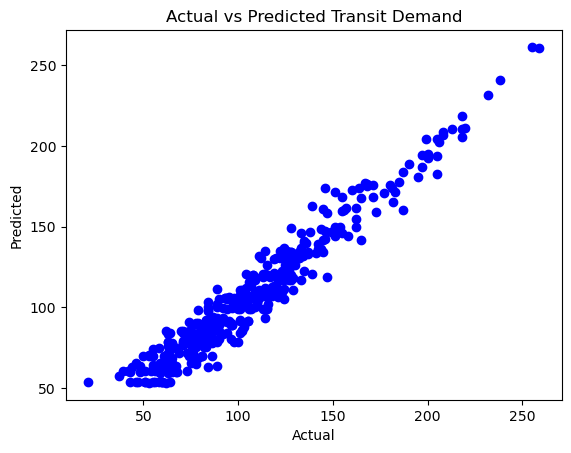

In [53]:

y_pred_final = best_model.predict(X_test_scaled)

print("Final R² Score:", r2_score(y_test, y_pred_final))
print("Final RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_final)))

plt.scatter(y_test, y_pred_final, color='blue')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Transit Demand")
plt.show()


<div style="font-family:'Times New Roman';">

  <h2 style="color:red; font-size:25px;">Output Interpretation</h2>

  <p style="color:darkblue; font-size:20px;">
    The printed values show the <strong>Final R² Score</strong> and <strong>Final RMSE</strong>, which indicate how well the model performs on unseen data.
  </p>

  <ul style="color:darkblue; font-size:20px;">
    <li><strong>R² Score (close to 1)</strong> indicates the model explains most of the variability in transit demand.</li>
    <li><strong>Low RMSE</strong> indicates the model's predictions are close to actual values, demonstrating good accuracy.</li>
  </ul>

  <p style="color:darkblue; font-size:20px;">
    The scatter plot below provides a visual performance check:
  </p>

  <ul style="color:darkblue; font-size:20px;">
    <li>Points lying close to the <strong>diagonal line</strong> indicate accurate predictions.</li>
    <li>Points far from the line indicate areas where the model underestimates or overestimates demand.</li>
  </ul>

  <p style="color:darkblue; font-size:20px;">
    Overall: a high R² and a tight scatter cluster near the diagonal imply the model generalizes well and is ready for deployment or further analysis.
  </p>

</div>
